# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

Pregnancies - Number of times pregnant;
Glucose - Plasma glucose concentration a 2 hours in an oral glucose tolerance test;
BloodPressure - Diastolic blood pressure (mm Hg);
SkinThickness - Triceps skin fold thickness (mm);
Insulin - 2-Hour serum insulin (mu U/ml);
BMI - Body mass index (weight in kg/(height in m)^2);
DiabetesPedigreeFunction - Diabetes pedigree function;
Age - Age (years);
Outcome - Class variable (0 or 1) 268 of 768 are 1, the others are 0;

In [1]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
def ModelPerformanceAnalysis(selected_model, X, y, test_size = 0.3, seed = 7):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    model = selected_model # Change model as required
    model.fit(X_train, y_train)
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score]
    
    #### Optimize probability threshold and calculate performance numbers
    y_predictProb = model.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
    optimalF1 = 0
    optimalTh = 0
    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
        f1Score = f1_score(y_train, preds)
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th

    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score"])
    # Optimal probability threshold based train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Optimal probability threshold based test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
    
    return resultsDf.round(2)

In [3]:
# evaluate each model in turn
def results_plot(metric, models, X, y, seed=7):
    results = []
    names = []
    scoring = metric # change evaluation metric as requred, example - accuracy, precision, f1, recall
    for name, model in models:
        kfold = model_selection.KFold(n_splits=5,random_state=seed)
        cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
        #print(msg)
    # boxplot algorithm comparison
    fig = plt.figure()
    fig.suptitle('Algorithm Comparison')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [4]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"

colnames = ['preg', 'gluc', 'BP', 'skin', 'insu', 'BMI', 'pedi', 'age', 'class']

#Load the file from local directory using pd.read_csv which is a special form of read_table
#while reading the data, supply the "colnames" list

pima_df = pd.read_csv("pima-indians-diabetes.data", names= colnames)

It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [5]:
pima_df.head(10)

,preg,gluc,BP,skin,insu,BMI,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [6]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
gluc     768 non-null int64
BP       768 non-null int64
skin     768 non-null int64
insu     768 non-null int64
BMI      768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
pima_df.shape

(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


In [8]:
zeros = 768 - pima_df.astype(bool).sum(axis=0)
zeros

preg     111
gluc       5
BP        35
skin     227
insu     374
BMI       11
pedi       0
age        0
class    500
dtype: int64

# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [9]:
median_preg = pima_df['preg'].median()
pima_df['preg']=pima_df.preg.mask(pima_df.preg == 0,median_preg)
median_gluc = pima_df['gluc'].median()
pima_df['gluc']=pima_df.gluc.mask(pima_df.gluc == 0,median_gluc)
median_BP = pima_df['BP'].median()
pima_df['BP']=pima_df.BP.mask(pima_df.BP == 0,median_BP)
median_skin = pima_df['skin'].median()
pima_df['skin']=pima_df.skin.mask(pima_df.skin == 0,median_skin)
median_insu = pima_df['insu'].median()
pima_df['insu']=pima_df.insu.mask(pima_df.insu == 0,median_insu)
median_BMI = pima_df['BMI'].median()
pima_df['BMI']=pima_df.BMI.mask(pima_df.BMI == 0,median_BMI)
median_pedi = pima_df['pedi'].median()
pima_df['pedi']=pima_df.pedi.mask(pima_df.pedi == 0,median_pedi)
median_age = pima_df['age'].median()
pima_df['age']=pima_df.age.mask(pima_df.age == 0,median_age)

zeros = 768 - pima_df.astype(bool).sum(axis=0)
zeros

preg       0
gluc       0
BP         0
skin       0
insu       0
BMI        0
pedi       0
age        0
class    500
dtype: int64

# Q5 Print the descriptive statistics of each & every column using describe() function

In [10]:
pima_df.describe(include='all')

,preg,gluc,BP,skin,insu,BMI,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.278646,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.021516,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

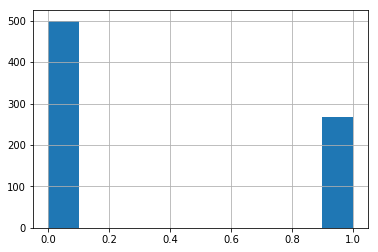

In [11]:
pima_df['class'].hist()

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000015DBF68E7F0>,
      dtype=object)

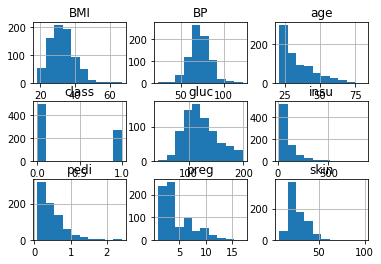

In [12]:
pima_df.hist()

### Observations: 1) Skin and insu attribute has outliers; 2) age, insu, pedi and preg have positive skew

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


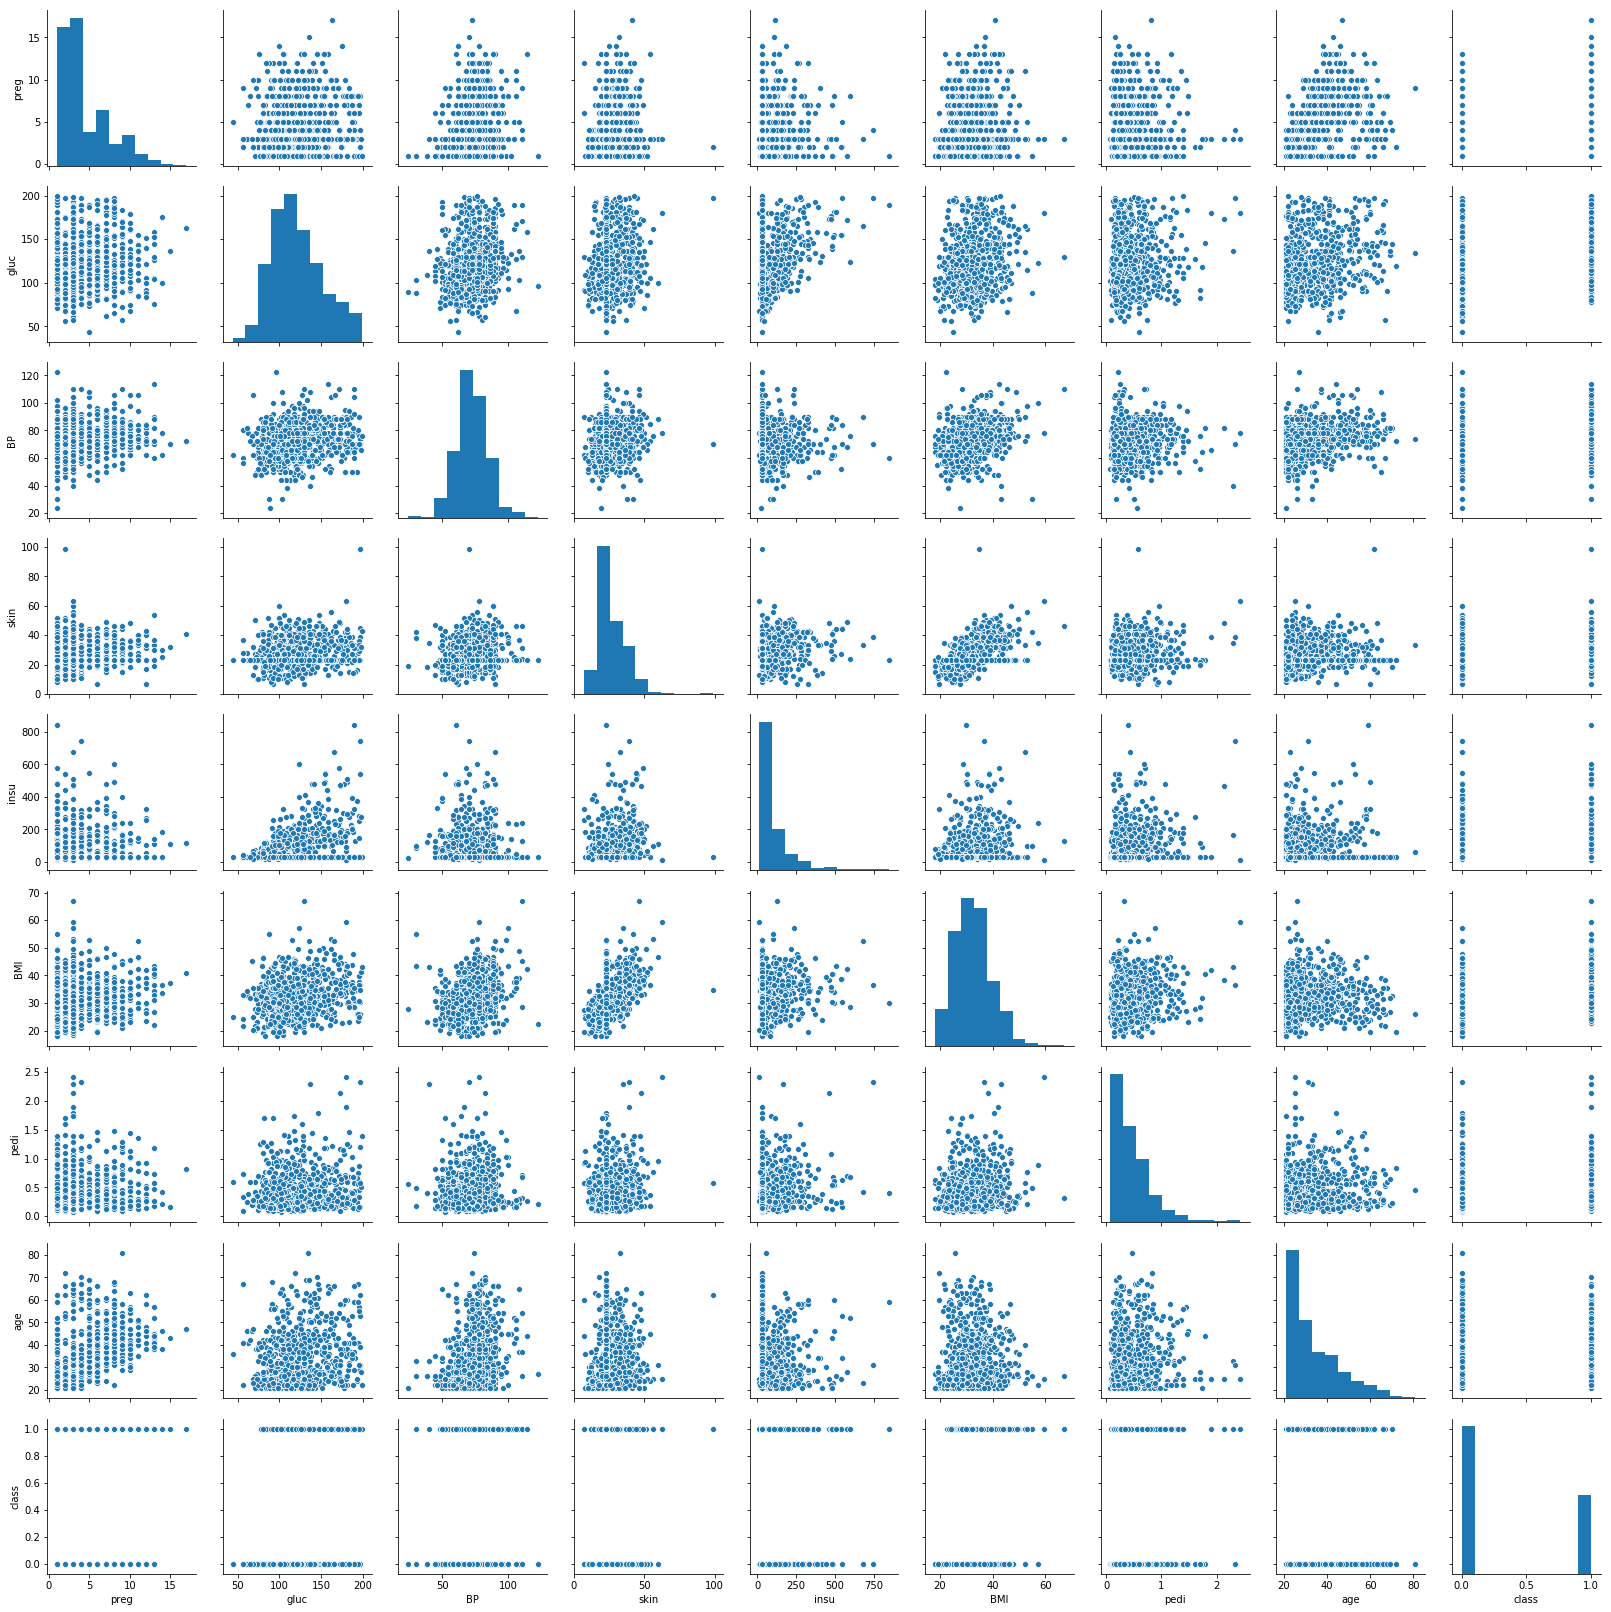

In [13]:
# Pairplot using sns
sns.pairplot(pima_df)

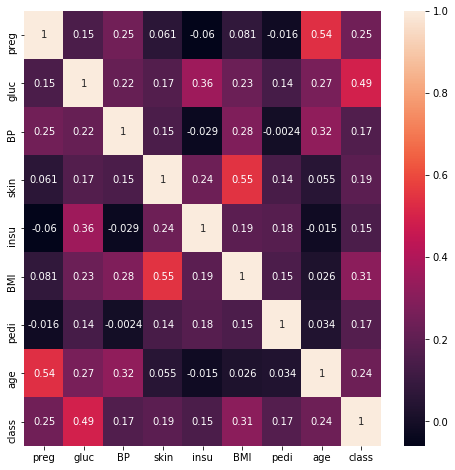

In [14]:
corr = pima_df.corr()
plt.figure(figsize=(8,8)) 
sns.heatmap(corr, annot=True)

Using the plot - infer the relationship between different variables

### Observation: Notable correlations recognized between BMI-skin(0.55), preg-age (0.54), gluc-class(0.49) and insu-gluc (0.36)

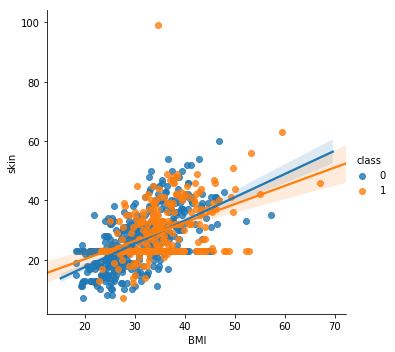

In [15]:
sns.lmplot(x = 'BMI', y = 'skin', hue="class", data = pima_df)

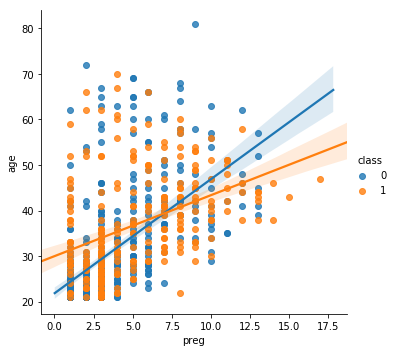

In [16]:
sns.lmplot(x = 'preg', y = 'age', hue="class", data = pima_df)

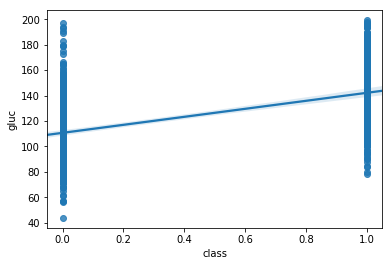

In [17]:
sns.regplot(x = 'class', y = 'gluc', data = pima_df)

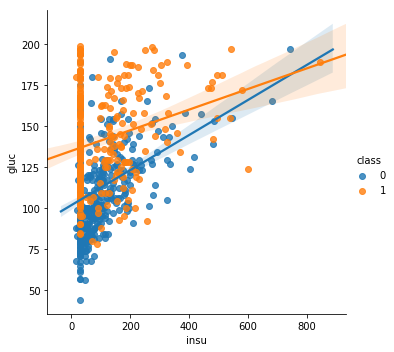

In [18]:
sns.lmplot(x = 'insu', y = 'gluc', hue="class", data = pima_df)

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [19]:
X =  pima_df.drop(['class'], axis=1)
y =  pima_df["class"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [20]:
DT = DecisionTreeClassifier(criterion = 'entropy', random_state=seed)
DT.fit(X_train, y_train)

parameter={'max_depth':np.arange(3,10)}
DT_GS=GridSearchCV(DT,parameter,cv=5)
DT_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(DT_GS.best_score_))
print("Best parameters: ", DT_GS.best_params_)

Best cross-validation score w/ kfold: 0.75
Best parameters:  {'max_depth': 4}


In [21]:
DT_model_GS = DecisionTreeClassifier(max_depth = 4, criterion = 'entropy',random_state=seed)
DT_model_GS.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=7,
            splitter='best')

# Q10 Print the accuracy of the model & print the confusion matrix 

In [22]:
ModelPerformanceAnalysis(DT_model_GS, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.0,231.00,537.00,231.00
optimalTh,0.5,0.50,0.29,0.29
accuracy,0.8,0.73,0.80,0.74
recall,0.7,0.75,0.88,0.88
precision,0.7,0.61,0.65,0.60
f1_score,0.7,0.67,0.75,0.71


In [23]:
DT_ypred = DT_model_GS.predict(X_test)
cm2=metrics.confusion_matrix(y_test,DT_ypred)
print(cm2)

[[106  41]
 [ 21  63]]


Print the feature importance of the decision model - Optional

In [24]:
DT_model_GS_feat_imp = pd.DataFrame(DT_model_GS.feature_importances_, columns = ["Imp"], index = X_train.columns)
DT_model_GS_feat_imp.sort_values(by=['Imp'], ascending=False)

,Imp
gluc,0.507298
BMI,0.241460
age,0.146780
pedi,0.051138
preg,0.027698
skin,0.016906
BP,0.008720
insu,0.000000


# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [25]:
RF = RandomForestClassifier()
RF.fit(X_train, y_train)

parameter={'n_estimators':np.arange(5,25),'max_depth':np.arange(3,10),'criterion' : ['gini','entropy']}
RF_GS=GridSearchCV(RF,parameter,cv=5)
RF_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(RF_GS.best_score_))
print("Best parameters: ", RF_GS.best_params_)

Best cross-validation score w/ kfold: 0.79
Best parameters:  {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 16}


C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [26]:
RF_model_GS = RandomForestClassifier(n_estimators = 16, max_depth = 5, criterion = 'entropy',random_state=seed)
RF_model_GS.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=5, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=16, n_jobs=None,
            oob_score=False, random_state=7, verbose=0, warm_start=False)

In [27]:
ModelPerformanceAnalysis(RF_model_GS, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.00,231.00,537.00,231.00
optimalTh,0.50,0.50,0.43,0.43
accuracy,0.86,0.76,0.86,0.75
recall,0.71,0.63,0.83,0.73
precision,0.85,0.69,0.77,0.64
f1_score,0.78,0.66,0.80,0.68


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [28]:
boost_rf = AdaBoostClassifier(base_estimator=RF_model_GS,n_estimators=50,random_state=seed)
boost_rf.fit(X_train, y_train)

parameter={'n_estimators':np.arange(5,50), 'learning_rate':np.arange(1,10)}
AdaBoost_RF_GS=GridSearchCV(boost_rf,parameter,cv=5)
AdaBoost_RF_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(AdaBoost_RF_GS.best_score_))
print("Best parameters: ", AdaBoost_RF_GS.best_params_)

Best cross-validation score w/ kfold: 0.77
Best parameters:  {'learning_rate': 1, 'n_estimators': 9}


C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [29]:
AdaBoost_RF_GS = AdaBoostClassifier(base_estimator=RF_model_GS,n_estimators=9,learning_rate=1,random_state=seed)

In [30]:
ModelPerformanceAnalysis(AdaBoost_RF_GS, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.00,231.00,537.00,231.00
optimalTh,0.50,0.50,0.50,0.50
accuracy,0.97,0.74,0.97,0.75
recall,0.95,0.62,0.94,0.62
precision,0.98,0.65,0.98,0.67
f1_score,0.96,0.63,0.96,0.64


In [31]:
boost_dt = AdaBoostClassifier(base_estimator=DT_model_GS,n_estimators=50,random_state=seed)
boost_dt.fit(X_train, y_train)

parameter={'n_estimators':np.arange(5,50), 'learning_rate':np.arange(1,10)}
AdaBoost_DT_GS=GridSearchCV(boost_dt,parameter,cv=5)
AdaBoost_DT_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(AdaBoost_DT_GS.best_score_))
print("Best parameters: ", AdaBoost_DT_GS.best_params_)

Best cross-validation score w/ kfold: 0.75
Best parameters:  {'learning_rate': 1, 'n_estimators': 45}


C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [32]:
AdaBoost_DT_GS = AdaBoostClassifier(base_estimator=DT_model_GS,n_estimators=45,learning_rate=1,random_state=seed)

In [33]:
ModelPerformanceAnalysis(AdaBoost_DT_GS, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.0,231.00,537.00,231.00
optimalTh,0.5,0.50,0.74,0.74
accuracy,1.0,0.72,1.00,0.71
recall,1.0,0.65,0.99,0.37
precision,1.0,0.61,1.00,0.70
f1_score,1.0,0.63,1.00,0.48


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [34]:
bag_dt = BaggingClassifier(base_estimator=DT_model_GS,n_estimators=50,random_state=seed)
bag_dt.fit(X_train, y_train)

parameter={'n_estimators':np.arange(5,50)}
Bag_DT_GS=GridSearchCV(bag_dt,parameter,cv=5)
Bag_DT_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(Bag_DT_GS.best_score_))
print("Best parameters: ", Bag_DT_GS.best_params_)

Best cross-validation score w/ kfold: 0.76
Best parameters:  {'n_estimators': 21}


In [35]:
Bag_DT_GS = BaggingClassifier(base_estimator=DT_model_GS,n_estimators=21,random_state=seed)

In [36]:
ModelPerformanceAnalysis(Bag_DT_GS, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.00,231.00,537.00,231.00
optimalTh,0.50,0.50,0.44,0.44
accuracy,0.83,0.77,0.83,0.75
recall,0.76,0.74,0.83,0.80
precision,0.74,0.67,0.72,0.62
f1_score,0.75,0.70,0.77,0.70


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [37]:
Gboost = GradientBoostingClassifier()
Gboost.fit(X_train,y_train)

parameter={'n_estimators':np.arange(80,120), 'learning_rate':np.arange(0.1,2), 'loss': ['deviance','exponential']}
Gboost_GS=GridSearchCV(Gboost,parameter,cv=5)
Gboost_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(Gboost_GS.best_score_))
print("Best parameters: ", Gboost_GS.best_params_)

Best cross-validation score w/ kfold: 0.77
Best parameters:  {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 88}


C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


In [38]:
Gboost_GS = GradientBoostingClassifier(n_estimators=88,loss='exponential',learning_rate=0.1,random_state=seed)

In [39]:
ModelPerformanceAnalysis(Gboost_GS, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.00,231.00,537.00,231.00
optimalTh,0.50,0.50,0.34,0.34
accuracy,0.91,0.77,0.91,0.75
recall,0.83,0.68,0.95,0.80
precision,0.89,0.68,0.82,0.62
f1_score,0.86,0.68,0.88,0.70


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [40]:
stacked = VotingClassifier(estimators = [('DT', DT_model_GS),('AB_DT', AdaBoost_DT_GS), ('B_DT', Bag_DT_GS), 
                                        ('RF', RF_model_GS), ('AB_RF', AdaBoost_RF_GS), ('GB', Gboost_GS)],voting='soft')

In [41]:
ModelPerformanceAnalysis(stacked, X, y, test_size = 0.3, seed = 7)

C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\85jat\Anaconda3new\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,537.00,231.00,537.00,231.00
optimalTh,0.50,0.50,0.54,0.54
accuracy,0.94,0.77,0.94,0.76
recall,0.88,0.71,0.85,0.62
precision,0.94,0.67,0.98,0.69
f1_score,0.91,0.69,0.91,0.65


In [42]:
stacked_h = VotingClassifier(estimators = [('DT', DT_model_GS),('AB_DT', AdaBoost_DT_GS), ('B_DT', Bag_DT_GS), 
                                        ('RF', RF_model_GS), ('AB_RF', AdaBoost_RF_GS), ('GB', Gboost_GS)],voting='hard')

In [43]:
stacked_h.fit(X_train, y_train)
ypred_STKh = stacked_h.predict(X_test)

In [44]:
accuracy_score(y_test, ypred_STKh)

0.7619047619047619

In [45]:
models = []
models.append(('DT', DT_model_GS))
models.append(('AB_DT', AdaBoost_DT_GS))
models.append(('B_DT', Bag_DT_GS))
models.append(('RF', RF_model_GS))
models.append(('AB_RF', AdaBoost_RF_GS))
models.append(('GB', Gboost_GS))
models.append(('STK', stacked))
models.append(('STKh', stacked_h))

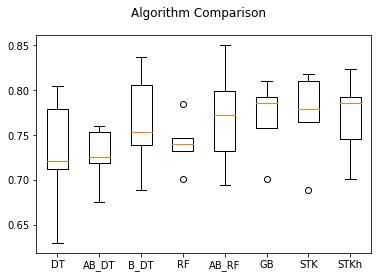

In [46]:
results_plot('accuracy', models, X, y, seed=7)

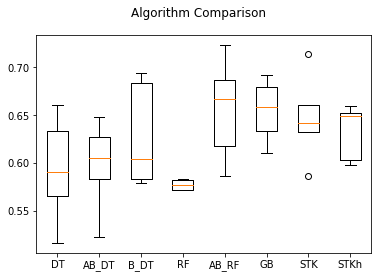

In [47]:
results_plot('f1', models, X, y, seed=7)

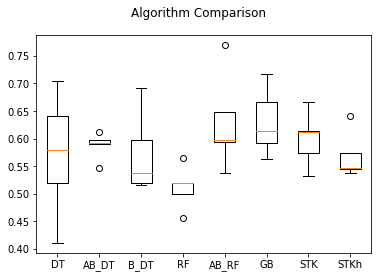

In [48]:
results_plot('recall', models, X, y, seed=7)

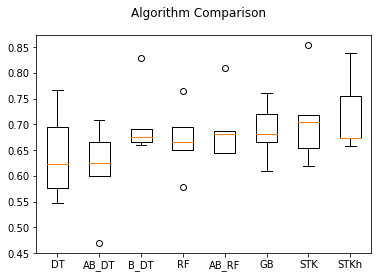

In [49]:
results_plot('precision', models, X, y, seed=7)

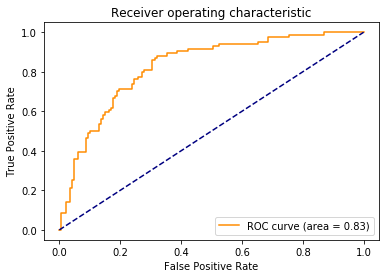

In [50]:
y_pred_GB = Gboost_GS.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_GB[::,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")